# AI Waste Sorter

### Project Overview
In this project we try to build an AI model that can classify the kind of waste into 12 classes from images.

# CNN Model Building

This notebook contain process of building various CNN models. We will build 3 CNN architecture with different complexity and compare the performance.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support

import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

if tf.config.list_physical_devices('GPU'):
    print("Using GPU")
    for gpu in tf.config.list_physical_devices('GPU'):
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("Using CPU")

2026-01-29 18:34:59.433048: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using GPU


## 1. Configuration & Setup

In [2]:
BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR / 'processed_data'
TRAIN_DIR = PROCESSED_DIR / 'train_balanced'
VAL_DIR = PROCESSED_DIR / 'val'
TEST_DIR = PROCESSED_DIR / 'test'
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 100
NUM_CLASSES = 12

with open(PROCESSED_DIR / 'balanced_dataset_info.json', 'r') as f:
    balanced_info = json.load(f)

category_to_index = balanced_info['category_mapping']['category_to_index']
index_to_category = {int(k): v for k, v in balanced_info['category_mapping']['index_to_category'].items()}

print(f"Train directory: {TRAIN_DIR}")
print(f"Validation directory: {VAL_DIR}")
print(f"Test directory: {TEST_DIR}")
print(f"Models directory: {MODELS_DIR}")
print(f"\nImage size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Number of classes: {NUM_CLASSES}")

Train directory: /mnt/d/personal/AI and Machine Learning/waste sorter ai/processed_data/train_balanced
Validation directory: /mnt/d/personal/AI and Machine Learning/waste sorter ai/processed_data/val
Test directory: /mnt/d/personal/AI and Machine Learning/waste sorter ai/processed_data/test
Models directory: /mnt/d/personal/AI and Machine Learning/waste sorter ai/models

Image size: (224, 224)
Batch size: 32
Epochs: 100
Number of classes: 12


## 2. Data Generators with Augmentation

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nTrain samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")
print(f"\nClass indices: {train_generator.class_indices}")

Found 8424 images belonging to 12 classes.
Found 1550 images belonging to 12 classes.
Found 1556 images belonging to 12 classes.

Train samples: 8424
Validation samples: 1550
Test samples: 1556

Class indices: {'battery': 0, 'biological': 1, 'brown-glass': 2, 'cardboard': 3, 'clothes': 4, 'green-glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'white-glass': 11}


## 3. CNN Architecture 1 - Simple Baseline

In [4]:
def create_simple_cnn(input_shape=(224, 224, 3), num_classes=12):
    """
    Simple CNN with 3 convolutional blocks and ~2M parameters
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='SimpleCNN')
    
    return model

model_simple = create_simple_cnn()
model_simple.summary()

I0000 00:00:1769686550.488692    8583 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,788,620 (98.38 MB)

 Trainable params: 25,787,660 (98.37 MB)

 Non-trainable params: 960 (3.75 KB)

## 4. CNN Architecture 2 - Medium Complexity

In [5]:
def create_medium_cnn(input_shape=(224, 224, 3), num_classes=12):
    """
    CNN with 4 convolutional blocks and more filters and ~5M parameters
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),
        
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='MediumCNN')
    
    return model

model_medium = create_medium_cnn()
model_medium.summary()

Model: "MediumCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,412,204 (100.75 MB)

 Trainable params: 26,409,708 (100.75 MB)

 Non-trainable params: 2,496 (9.75 KB)

## 5. CNN Architecture 3 - Deeper Network

In [6]:
def create_deep_cnn(input_shape=(224, 224, 3), num_classes=12):
    """
    Deeper CNN architecture with 5 convolutional blocks and ~8M parameters
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),
        
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),
        
        layers.Flatten(),
        layers.Dense(1024, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='DeepCNN')
    
    return model

model_deep = create_deep_cnn()
model_deep.summary()

Model: "DeepCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 28,584,620 (109.04 MB)

 Trainable params: 28,579,564 (109.02 MB)

 Non-trainable params: 5,056 (19.75 KB)

## 6. Training Configuration

In [7]:
def get_callbacks(model_name):
    """
    Callbacks setup for training
    """
    model_path = MODELS_DIR / f'{model_name}_best.keras'
    
    callbacks_list = [
        callbacks.ModelCheckpoint(
            filepath=str(model_path),
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    return callbacks_list

print("Callbacks configuration:")
print("- ModelCheckpoint for saving model with best val_accuracy")
print("- ReduceLROnPlateau to reduce learning rate by 0.5 if val_loss doesn't improve for 5 epochs")

Callbacks configuration:
- ModelCheckpoint for saving model with best val_accuracy
- ReduceLROnPlateau to reduce learning rate by 0.5 if val_loss doesn't improve for 5 epochs


## 7. Training Helper Functions

In [8]:
def plot_training_history(history, model_name):
    """
    Plot training history
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0].set_title(f'{model_name} - Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[1].set_title(f'{model_name} - Loss', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(MODELS_DIR / f'{model_name}_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

def evaluate_model(model, test_generator, model_name):
    """
    Evaluate model and generate classification report
    """
    test_generator.reset()
    predictions = model.predict(test_generator, verbose=1)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_generator.classes
    
    accuracy = accuracy_score(y_true, y_pred)
    
    class_names = list(test_generator.class_indices.keys())
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    
    print(f"\n{model_name} Test Accuracy: {accuracy:.4f}")
    print(f"\nClassification Report:")
    print(report)
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(MODELS_DIR / f'{model_name}_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return accuracy, report, cm


## 8. Train First CNN Architecture

In [9]:
print("First Architecture CNN Training")
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

model_simple = create_simple_cnn()

model_simple.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_simple = model_simple.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=get_callbacks('simple_cnn'),
    verbose=1
)

print(f"\nCompleted at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

First Architecture CNN Training
Started at: 2026-01-29 18:35:52
Epoch 1/100


2026-01-29 18:35:56.170720: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f2600008170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-29 18:35:56.170753: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-01-29 18:35:56.298707: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-29 18:35:56.802924: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
2026-01-29 18:35:59.310749: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 532.00MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-01-29 18:36:02.364

  1/264 ━━━━━━━━━━━━━━━━━━━━ 1:02:59 14s/step - accuracy: 0.1250 - loss: 4.0959

I0000 00:00:1769686567.850316    8901 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.3315 - loss: 2.3494

2026-01-29 18:38:36.666738: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 532.00MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.



Epoch 1: val_accuracy improved from None to 0.06387, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/simple_cnn_best.keras
264/264 ━━━━━━━━━━━━━━━━━━━━ 186s 653ms/step - accuracy: 0.3892 - loss: 2.0575 - val_accuracy: 0.0639 - val_loss: 8.7834 - learning_rate: 0.0010
Epoch 2/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.4689 - loss: 1.7085
Epoch 2: val_accuracy improved from 0.06387 to 0.24645, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/simple_cnn_best.keras
264/264 ━━━━━━━━━━━━━━━━━━━━ 88s 333ms/step - accuracy: 0.4563 - loss: 1.7137 - val_accuracy: 0.2465 - val_loss: 3.9090 - learning_rate: 0.0010
Epoch 3/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.4796 - loss: 1.5976
Epoch 3: val_accuracy improved from 0.24645 to 0.26839, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/simple_cnn_best.keras
264/264 ━━━━━━━━━━━━━━━━━━━━ 83s 313ms/step - accuracy: 0.4925 -

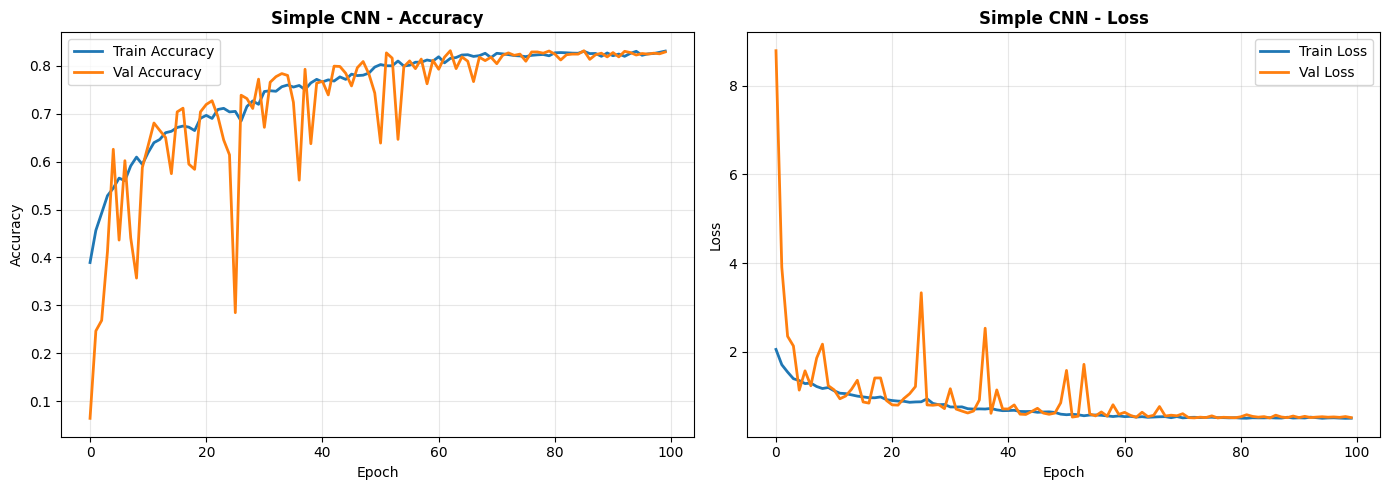

49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 445ms/step

Simple CNN Test Accuracy: 0.8149

Classification Report:
              precision    recall  f1-score   support

     battery     0.7524    0.8316    0.7900        95
  biological     0.8265    0.8182    0.8223        99
 brown-glass     0.7812    0.8197    0.8000        61
   cardboard     0.8556    0.8556    0.8556        90
     clothes     0.9065    0.9099    0.9082       533
 green-glass     0.9180    0.8889    0.9032        63
       metal     0.7534    0.7143    0.7333        77
       paper     0.7154    0.8857    0.7915       105
     plastic     0.5872    0.7356    0.6531        87
       shoes     0.7812    0.6313    0.6983       198
       trash     0.9348    0.6143    0.7414        70
 white-glass     0.7059    0.7692    0.7362        78

    accuracy                         0.8149      1556
   macro avg     0.7932    0.7895    0.7861      1556
weighted avg     0.8216    0.8149    0.8144      1556



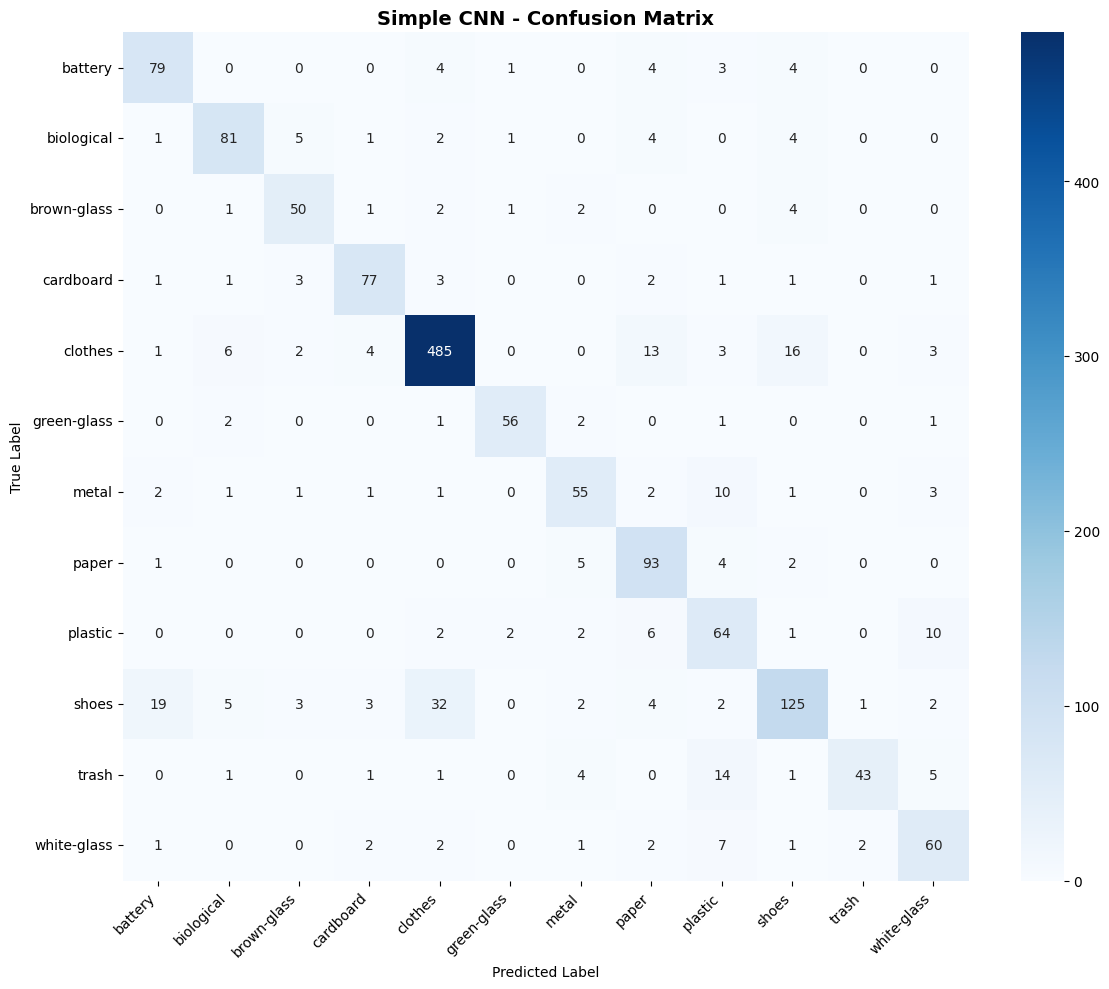

In [10]:
plot_training_history(history_simple, 'Simple CNN')

model_simple.load_weights(str(MODELS_DIR / 'simple_cnn_best.keras'))
acc_simple, report_simple, cm_simple = evaluate_model(model_simple, test_generator, 'Simple CNN')

## 9. Train Medium CNN Architecture

In [ ]:
print("Medium CNN Training")
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

model_medium = create_medium_cnn()

model_medium.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_medium = model_medium.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=get_callbacks('medium_cnn'),
    verbose=1
)

print(f"\nCompleted at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

In [ ]:
plot_training_history(history_medium, 'Medium CNN')

model_medium.load_weights(str(MODELS_DIR / 'medium_cnn_best.keras'))
acc_medium, report_medium, cm_medium = evaluate_model(model_medium, test_generator, 'Medium CNN')

## 10. Train Deeper CNN Architecture

In [ ]:
print("Training Deeper CNN")
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

model_deep = create_deep_cnn()

model_deep.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_deep = model_deep.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=get_callbacks('deep_cnn'),
    verbose=1
)

print(f"\nCompleted at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

In [ ]:
plot_training_history(history_deep, 'Deep CNN')

model_deep.load_weights(str(MODELS_DIR / 'deep_cnn_best.keras'))
acc_deep, report_deep, cm_deep = evaluate_model(model_deep, test_generator, 'Deep CNN')

## 11. Compare All Models

In [ ]:
results_comparison = pd.DataFrame({
    'Model': ['Simple CNN', 'Medium CNN', 'Deep CNN'],
    'Parameters': [
        model_simple.count_params(),
        model_medium.count_params(),
        model_deep.count_params()
    ],
    'Test Accuracy': [acc_simple, acc_medium, acc_deep],
    'Best Val Accuracy': [
        max(history_simple.history['val_accuracy']),
        max(history_medium.history['val_accuracy']),
        max(history_deep.history['val_accuracy'])
    ],
    'Final Train Accuracy': [
        history_simple.history['accuracy'][-1],
        history_medium.history['accuracy'][-1],
        history_deep.history['accuracy'][-1]
    ]
})

results_comparison['Parameters (M)'] = results_comparison['Parameters'] / 1e6

print("\nModel Comparison:")
print(results_comparison.to_string(index=False))

best_model_idx = results_comparison['Test Accuracy'].idxmax()
best_model_name = results_comparison.loc[best_model_idx, 'Model']
best_accuracy = results_comparison.loc[best_model_idx, 'Test Accuracy']

print(f"\nBest Model: {best_model_name} with {best_accuracy:.4f} test accuracy")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

results_comparison.plot(x='Model', y='Test Accuracy', kind='bar', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Model')
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(results_comparison['Test Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

results_comparison.plot(x='Model', y='Parameters (M)', kind='bar', ax=axes[1], color='coral', legend=False)
axes[1].set_title('Model Size Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Parameters (Millions)')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(results_comparison['Parameters (M)']):
    axes[1].text(i, v + 0.1, f'{v:.2f}M', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Save Training Results

In [ ]:
training_results = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'configuration': {
        'image_size': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'num_classes': NUM_CLASSES
    },
    'models': {
        'simple_cnn': {
            'parameters': int(model_simple.count_params()),
            'test_accuracy': float(acc_simple),
            'best_val_accuracy': float(max(history_simple.history['val_accuracy'])),
            'final_train_accuracy': float(history_simple.history['accuracy'][-1])
        },
        'medium_cnn': {
            'parameters': int(model_medium.count_params()),
            'test_accuracy': float(acc_medium),
            'best_val_accuracy': float(max(history_medium.history['val_accuracy'])),
            'final_train_accuracy': float(history_medium.history['accuracy'][-1])
        },
        'deep_cnn': {
            'parameters': int(model_deep.count_params()),
            'test_accuracy': float(acc_deep),
            'best_val_accuracy': float(max(history_deep.history['val_accuracy'])),
            'final_train_accuracy': float(history_deep.history['accuracy'][-1])
        }
    },
    'best_model': {
        'name': best_model_name,
        'test_accuracy': float(best_accuracy)
    }
}

with open(MODELS_DIR / 'cnn_training_results.json', 'w') as f:
    json.dump(training_results, f, indent=2)

results_comparison.to_csv(MODELS_DIR / 'models_comparison.csv', index=False)

print("Training results saved")

## 13. Summary

In [ ]:
print("CNN BASELINE TRAINING COMPLETE")
print("\nSummary:")
print(f"- Trained 3 CNN architectures from scratch")
print(f"- Best model: {best_model_name}")
print(f"- Best test accuracy: {best_accuracy:.4f}")
print("\nFiles saved:")
print(f"- Model weights: {MODELS_DIR}/*_best.keras")
print(f"- Training history plots: {MODELS_DIR}/*_training_history.png")
print(f"- Confusion matrices: {MODELS_DIR}/*_confusion_matrix.png")
print(f"- Results summary: {MODELS_DIR}/cnn_training_results.json")
print("\nNext steps:")
print("1. Experiment with Transfer Learning (MobileNet, EfficientNet, ResNet)")
print("2. Fine-tune hyperparameters")
print("3. Compare with baseline CNN models")
print("4. Select best model for deployment")